# Fig6 — Station VRMSE under four surface conditions

Compute all-station 10 m wind vector RMSE (VRMSE) distributions for Ragasa and Yagi during the six-hour closest-approach windows. Each storm is exported as a separate four-case boxplot.

The four surface cases are Low terrain–Low LCZ, Low terrain–High LCZ, High terrain–Low LCZ, and High terrain–High LCZ. Only the two TIFF figures are written to `Fig6/output`; station-level VRMSE remains in memory.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd


def find_figs_dir() -> Path:
    """Locate the Figs workspace from either the workspace root or Fig6."""
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "Fig6/input").is_dir() and (candidate / "Fig5/input").is_dir():
            return candidate
    raise FileNotFoundError(f"Could not locate Fig5/input and Fig6/input from {cwd}")


FIGS_DIR = find_figs_dir()
FIG6_DIR = FIGS_DIR / "Fig6"
SIM_ROOT = FIG6_DIR / "input"
OBS_ROOT = FIGS_DIR / "Fig5/input"
OUTPUT_DIR = FIG6_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TS_COL = "timestamp_utc"
TS_FORMAT = "%Y%m%d %H%M"
EXPECTED_MINUTES = 6 * 60 + 1
DPI = 600

STORMS = {
    "ragasa": {
        "label": "Ragasa",
        "start": pd.Timestamp("2025-09-23 19:00", tz="UTC"),
        "end": pd.Timestamp("2025-09-24 01:00", tz="UTC"),
        "expected_stations": 30,
    },
    "yagi": {
        "label": "Yagi",
        "start": pd.Timestamp("2024-09-05 09:00", tz="UTC"),
        "end": pd.Timestamp("2024-09-05 15:00", tz="UTC"),
        "expected_stations": 31,
    },
}

CASE_ORDER = ["no_lcz_no_srtm", "no_srtm", "no_lcz", "lcz_srtm"]
CASE_META = {
    "no_lcz_no_srtm": {"label": "Low terrain\nLow LCZ", "color": "#9E9E9E"},
    "no_srtm": {"label": "Low terrain\nHigh LCZ", "color": "#66A182"},
    "no_lcz": {"label": "High terrain\nLow LCZ", "color": "#6E8BC3"},
    "lcz_srtm": {"label": "High terrain\nHigh LCZ", "color": "#C96A5A"},
}

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
FONT_FAMILY = "Arial" if "Arial" in available_fonts else "DejaVu Sans"
mpl.rcParams.update(
    {
        "font.family": FONT_FAMILY,
        "font.sans-serif": [FONT_FAMILY],
        "font.size": 16,
    }
)

csv_files_before = {path.resolve() for path in OUTPUT_DIR.glob("*.csv")}
print("[Paths] Simulation input:", SIM_ROOT)
print("[Paths] Observation input:", OBS_ROOT)
print("[Paths] Figure output:", OUTPUT_DIR)
print("[Font]", FONT_FAMILY)

[Paths] Simulation input: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\input
[Paths] Observation input: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig5\input
[Paths] Figure output: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\output
[Font] Arial


In [2]:
def save_tiff(fig: mpl.figure.Figure, path: Path) -> None:
    """Save a publication-resolution TIFF, using LZW when supported."""
    try:
        fig.savefig(
            path, dpi=DPI, format="tiff", bbox_inches="tight",
            pil_kwargs={"compression": "tiff_lzw"},
        )
    except TypeError:
        fig.savefig(path, dpi=DPI, format="tiff", bbox_inches="tight")


def read_station_csv(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(f"Missing station time series: {path}")
    frame = pd.read_csv(path, dtype={TS_COL: str})
    if TS_COL not in frame.columns:
        raise ValueError(f"Missing {TS_COL!r} in {path}")

    rename = {column: str(column).strip().lower() for column in frame.columns if column != TS_COL}
    if len(rename.values()) != len(set(rename.values())):
        raise ValueError(f"Duplicate station columns after normalization in {path}")
    frame = frame.rename(columns=rename)
    frame[TS_COL] = pd.to_datetime(
        frame[TS_COL].astype(str).str.strip(),
        format=TS_FORMAT, utc=True, errors="raise",
    )
    if frame[TS_COL].duplicated().any():
        raise ValueError(f"Duplicate timestamps in {path}")
    return frame.sort_values(TS_COL).reset_index(drop=True)


def subset_window(
    frame: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp,
    stations: list[str], source: Path,
) -> pd.DataFrame:
    missing_stations = sorted(set(stations) - set(frame.columns))
    extra_stations = sorted(set(frame.columns) - {TS_COL} - set(stations))
    if missing_stations or extra_stations:
        raise ValueError(
            f"Station mismatch in {source}: missing={missing_stations}, extra={extra_stations}"
        )
    data = frame.loc[frame[TS_COL].between(start, end), [TS_COL, *stations]].set_index(TS_COL)
    if len(data) != EXPECTED_MINUTES:
        raise RuntimeError(
            f"Expected {EXPECTED_MINUTES} records in {source.name} from {start} to {end}; "
            f"found {len(data)}"
        )
    return data.apply(pd.to_numeric, errors="coerce")


def load_observed_uv(
    storm_key: str, start: pd.Timestamp, end: pd.Timestamp,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    storm_dir = OBS_ROOT / storm_key
    speed_path = storm_dir / "mean_wspd_obs.csv"
    direction_path = storm_dir / "mean_wdir_obs.csv"
    speed_raw = read_station_csv(speed_path)
    direction_raw = read_station_csv(direction_path)

    stations = [column for column in speed_raw.columns if column != TS_COL]
    direction_stations = [column for column in direction_raw.columns if column != TS_COL]
    if stations != direction_stations:
        raise ValueError(f"Observation speed/direction station order differs for {storm_key}")

    speed = subset_window(speed_raw, start, end, stations, speed_path)
    direction = subset_window(direction_raw, start, end, stations, direction_path)
    if not speed.index.equals(direction.index):
        raise RuntimeError(f"Observation speed/direction timestamps differ for {storm_key}")

    missing = speed.eq(32767) | direction.eq(32767) | (speed.eq(0.0) & direction.eq(0.0))
    speed = speed.mask(missing)
    direction = direction.mask(missing)
    theta = np.deg2rad(direction)
    u = -speed * np.sin(theta)
    v = -speed * np.cos(theta)
    return u, v


def load_simulated_uv(
    storm_key: str, case_key: str, start: pd.Timestamp, end: pd.Timestamp,
    stations: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    storm_dir = SIM_ROOT / storm_key
    u_path = storm_dir / f"{case_key}_u_sim.csv"
    v_path = storm_dir / f"{case_key}_v_sim.csv"
    u = subset_window(read_station_csv(u_path), start, end, stations, u_path)
    v = subset_window(read_station_csv(v_path), start, end, stations, v_path)
    if not u.index.equals(v.index):
        raise RuntimeError(f"Simulation u/v timestamps differ for {storm_key} {case_key}")
    return u, v


def vector_rmse_by_station(
    obs_u: pd.DataFrame, obs_v: pd.DataFrame,
    sim_u: pd.DataFrame, sim_v: pd.DataFrame,
) -> pd.Series:
    if not (obs_u.index.equals(obs_v.index) and obs_u.index.equals(sim_u.index) and obs_u.index.equals(sim_v.index)):
        raise RuntimeError("Observation and simulation timestamps are not identical")
    if not (list(obs_u.columns) == list(obs_v.columns) == list(sim_u.columns) == list(sim_v.columns)):
        raise RuntimeError("Observation and simulation station columns are not identical")

    squared_vector_error = (sim_u - obs_u) ** 2 + (sim_v - obs_v) ** 2
    vrmse = np.sqrt(squared_vector_error.mean(axis=0, skipna=True)).rename("vrmse")
    if not np.isfinite(vrmse.to_numpy(dtype=float)).all():
        bad = vrmse.index[~np.isfinite(vrmse.to_numpy(dtype=float))].tolist()
        raise RuntimeError(f"Non-finite station VRMSE: {bad}")
    return vrmse

In [3]:
storm_results: dict[str, dict] = {}
summary_records: list[dict] = []

for storm_key, storm in STORMS.items():
    start = storm["start"]
    end = storm["end"]
    obs_u, obs_v = load_observed_uv(storm_key, start, end)
    stations = list(obs_u.columns)
    if len(stations) != storm["expected_stations"]:
        raise RuntimeError(
            f"Expected {storm['expected_stations']} stations for {storm['label']}; "
            f"found {len(stations)}"
        )

    values_by_case: dict[str, np.ndarray] = {}
    for case_key in CASE_ORDER:
        sim_u, sim_v = load_simulated_uv(
            storm_key, case_key, start, end, stations
        )
        if not sim_u.index.equals(obs_u.index) or not sim_v.index.equals(obs_v.index):
            raise RuntimeError(f"Observation/simulation timestamps differ for {storm_key} {case_key}")

        vrmse = vector_rmse_by_station(obs_u, obs_v, sim_u, sim_v)
        if len(vrmse) != storm["expected_stations"]:
            raise RuntimeError(f"Unexpected finite VRMSE count for {storm_key} {case_key}")
        values_by_case[case_key] = vrmse.to_numpy(dtype=float)
        summary_records.append(
            {
                "storm": storm["label"],
                "surface_case": CASE_META[case_key]["label"].replace("\n", " / "),
                "minutes": len(sim_u),
                "stations": len(vrmse),
                "median_vrmse": float(vrmse.median()),
                "mean_vrmse": float(vrmse.mean()),
            }
        )

    storm_results[storm_key] = {
        "metadata": storm,
        "stations": stations,
        "values_by_case": values_by_case,
    }
    print(
        f"{storm['label']}: {start} to {end}; {len(obs_u)} minutes; "
        f"{len(stations)} stations; {len(values_by_case)} surface cases"
    )

summary = pd.DataFrame(summary_records)
display(summary)

Ragasa: 2025-09-23 19:00:00+00:00 to 2025-09-24 01:00:00+00:00; 361 minutes; 30 stations; 4 surface cases


Yagi: 2024-09-05 09:00:00+00:00 to 2024-09-05 15:00:00+00:00; 361 minutes; 31 stations; 4 surface cases


,storm,surface_case,minutes,stations,median_vrmse,mean_vrmse
0,Ragasa,Low terrain / Low LCZ,361,30,23.754713,24.053769
1,Ragasa,Low terrain / High LCZ,361,30,16.948958,20.000504
2,Ragasa,High terrain / Low LCZ,361,30,24.070788,24.449136
3,Ragasa,High terrain / High LCZ,361,30,17.515430,19.719558
4,Yagi,Low terrain / Low LCZ,361,31,8.525926,8.720918
5,Yagi,Low terrain / High LCZ,361,31,6.910770,7.473544
6,Yagi,High terrain / Low LCZ,361,31,8.668893,8.962032
7,Yagi,High terrain / High LCZ,361,31,7.208624,8.120527


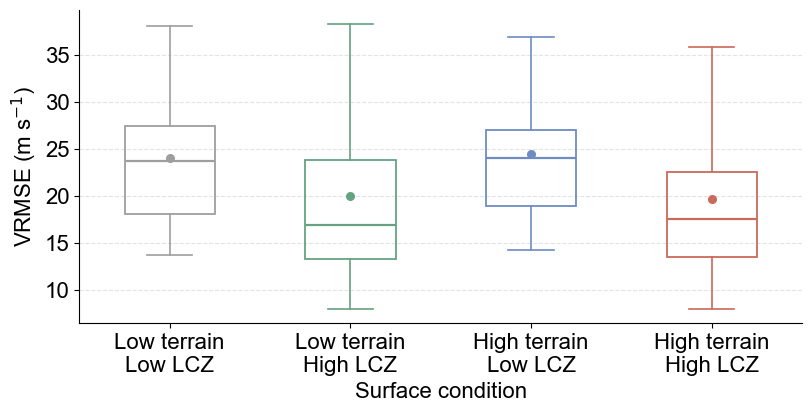

Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\output\vrmse_terrain_lcz_box_ragasa_20250923-19_to_20250924-01_24h_surface_cases.tif


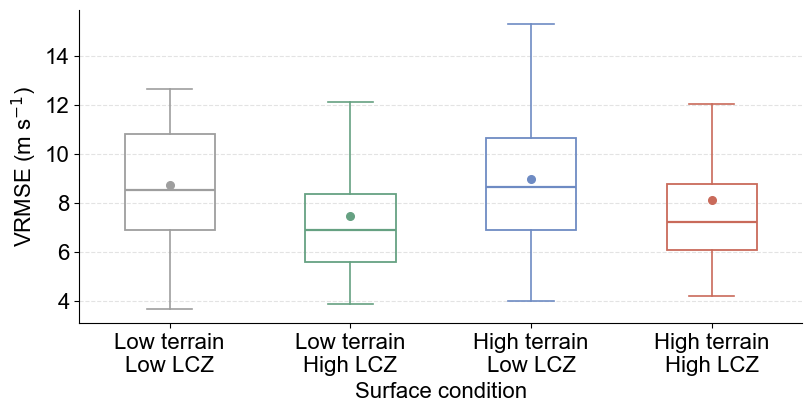

Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\output\vrmse_terrain_lcz_box_yagi_20240905-09_to_20240905-15_24h_surface_cases.tif
Validated two non-empty TIFF figures and no new CSV output.


[WindowsPath('E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig6/output/vrmse_terrain_lcz_box_ragasa_20250923-19_to_20250924-01_24h_surface_cases.tif'),
 WindowsPath('E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig6/output/vrmse_terrain_lcz_box_yagi_20240905-09_to_20240905-15_24h_surface_cases.tif')]

In [4]:
def plot_storm_boxplot(storm_key: str, result: dict) -> Path:
    metadata = result["metadata"]
    case_values = [result["values_by_case"][case_key] for case_key in CASE_ORDER]
    case_labels = [CASE_META[case_key]["label"] for case_key in CASE_ORDER]
    case_colors = [CASE_META[case_key]["color"] for case_key in CASE_ORDER]
    positions = np.arange(len(CASE_ORDER), dtype=float)

    fig, ax = plt.subplots(figsize=(8.4, 4.4))
    boxplot = ax.boxplot(
        case_values,
        positions=positions,
        widths=0.50,
        patch_artist=True,
        showfliers=False,
        showmeans=True,
        meanline=False,
        boxprops={"linewidth": 1.3},
        medianprops={"color": "black", "linewidth": 1.5},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2},
        meanprops={
            "marker": "o",
            "markersize": 5.5,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 1.0,
        },
    )

    for color, box in zip(case_colors, boxplot["boxes"]):
        box.set_facecolor("none")
        box.set_edgecolor(color)
        box.set_linewidth(1.3)
    for index, color in enumerate(case_colors):
        for artist in boxplot["whiskers"][2 * index : 2 * index + 2]:
            artist.set_color(color)
        for artist in boxplot["caps"][2 * index : 2 * index + 2]:
            artist.set_color(color)
        boxplot["medians"][index].set_color(color)
        boxplot["medians"][index].set_linewidth(1.6)
        boxplot["means"][index].set_markerfacecolor(color)
        boxplot["means"][index].set_markeredgecolor(color)
        boxplot["means"][index].set_zorder(3)

    ax.set_xticks(positions)
    ax.set_xticklabels(case_labels)
    ax.set_xlabel("Surface condition")
    ax.set_ylabel("VRMSE (m s$^{-1}$)")
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    window_tag = f"{metadata['start']:%Y%m%d-%H}_to_{metadata['end']:%Y%m%d-%H}"
    output_path = OUTPUT_DIR / (
        f"vrmse_terrain_lcz_box_{storm_key}_{window_tag}_24h_surface_cases.tif"
    )
    save_tiff(fig, output_path)
    plt.show()
    plt.close(fig)
    print("Saved:", output_path)
    return output_path


generated_paths = [
    plot_storm_boxplot(storm_key, result)
    for storm_key, result in storm_results.items()
]

if len(generated_paths) != 2:
    raise RuntimeError(f"Expected two generated figures; found {len(generated_paths)}")
for path in generated_paths:
    if not path.is_file() or path.stat().st_size == 0:
        raise RuntimeError(f"Missing or empty output figure: {path}")
csv_files_after = {path.resolve() for path in OUTPUT_DIR.glob("*.csv")}
if csv_files_after != csv_files_before:
    new_csvs = sorted(str(path) for path in csv_files_after - csv_files_before)
    raise RuntimeError(f"Unexpected CSV output(s): {new_csvs}")

print("Validated two non-empty TIFF figures and no new CSV output.")
generated_paths